# Chapter 9: Machine Learning Intro 1

In [41]:
low_memory=False
import matplotlib.image as img
import matplotlib.pyplot as plt

import copy
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from os import listdir
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
import seaborn as sns; sns.set()
from sklearn import metrics

## 9.1 Introduction & Problem Setting

Let's put everything to the test! Starting with a raw dataset, you'll create a model and evaluate its performance. Then you'll perform proper data processing to see how the results improve! 🌟

Your goal is to predict the spectral class of a new star. You have a dataset containing metrics like size, color, temperature, and more from different stars. The dataset includes the following columns:

- Temperature (K): Absolute Temperature (in K)
- Luminosity (L/Lo): Relative Luminosity (L/Lo)
- Radius (R/Ro): Relative Radius (R/Ro)
- Absolute magnitude (Mv): Absolute Magnitude (Mv)
- Star category: Star Category (Red Dwarf, Brown Dwarf, White Dwarf, Main Sequence, SuperGiants, HyperGiants)
- Star color: Star Color (white, Red, Blue, Yellow, yellow-orange, etc.)
- Spectral Class: Spectral Class (O, B, A, F, G, K, M)
- Spectral Type: Spectral Class encoded as integers

Lo = 3.828 x 10^26 Watts (Average Luminosity of Sun)
Ro = 6.9551 x 10^8 m (Average Radius of Sun)

## 9.2 Creating and Evaluating Your First Model

Create your first model using the data as provided (no modifications yet). Use 'Spectral Class' as your Y variable. Consider which columns are suitable for your model right now and why. Only use those appropriate columns as X.

Evaluate your model by creating a confusion matrix heatmap of your predictions. Remember to use only 25% of your total dataset for testing!

**Make sure to avoid a data leak!**

*Hint: You can use the RandomForest model from the notebook as your starting model.*

In [42]:
stars = pd.read_csv ('Stars.csv')
stars.head()

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star category,Star color,Spectral Class,Spectral Type
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M,5
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M,5
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M,5
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M,5
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M,5


In [43]:
stars.dtypes

Temperature (K)              int64
Luminosity (L/Lo)          float64
Radius (R/Ro)              float64
Absolute magnitude (Mv)    float64
Star category               object
Star color                  object
Spectral Class              object
Spectral Type                int64
dtype: object

The columns 'Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)' and 'Spectral Type' are integers, so we can use these columns to train our model.

In [44]:
X = stars[['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Spectral Type']]
Y = stars['Spectral Class']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25) 

In [45]:
X_train.shape

(180, 5)

In [46]:
X_test.shape

(60, 5)

In [47]:
ML_model = RandomForestClassifier()
ML_model.fit(X_train, y_train)
ML_model

RandomForestClassifier()

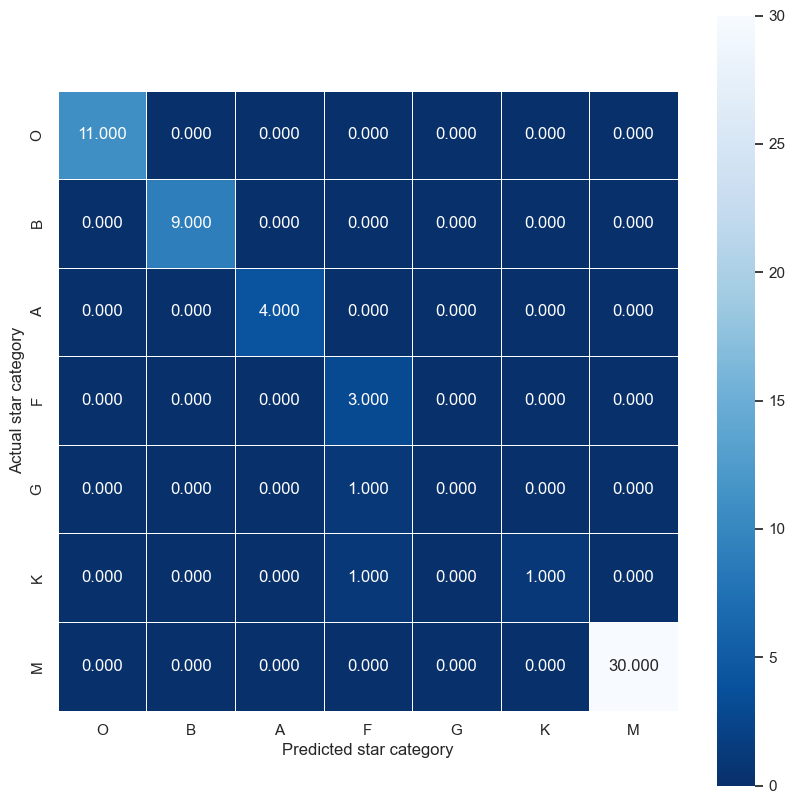

In [48]:
y_pred = ML_model.predict(X_test)

labels = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual star category');
plt.xlabel('Predicted star category');

We can draw two key conclusions from this result.

First, there are no 'G' stars in our test dataset. This is possible since we don't know which records ended up in that 25%.

Second, the model makes only a single mistake. This is highly suspicious and suggests a data leak. Looking at the input variables, we can spot the problem: the 'Spectral Type' column. While it's an integer (and therefore suitable for machine learning), we need to think about what it represents. It contains the same information as 'Spectral Class' (our Y variable), but just encoded as integers! By including this in X, we've created a data leak.

Let's fix this by creating a new model without the 'Spectral Type' variable.

In [49]:
X = stars[['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)']]
Y = stars['Spectral Class']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.5) 

In [50]:
X_train.shape

(120, 4)

In [51]:
X_test.shape

(120, 4)

In [52]:
ML_model = RandomForestClassifier()
ML_model.fit(X_train, y_train)
ML_model

RandomForestClassifier()

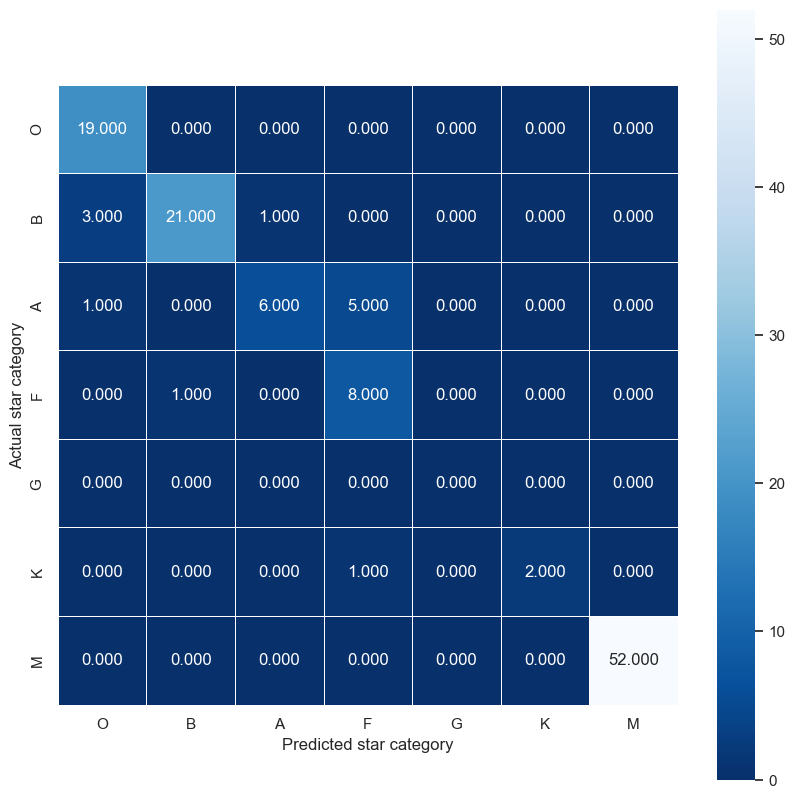

In [53]:
y_pred = ML_model.predict(X_test)

labels = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual star category');
plt.xlabel('Predicted star category');

While a heatmap is useful, it is not always clear which model is better when comparing several of them. That's why we generally use an **accuracy score**. This score tells us how well the model is performing, and how many predictions it has correct. Calculate the accuracy score of your model and interpret it. Is your model any good?

**https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier.score**
```
score = model.score()
```

In [54]:
ML_model.score(X_test, y_test)

0.9

We have an accuracy score of 0.9, meaning 90% of our predictions are correct. That's excellent! 🏅

## 9.3: Data Processing

Explore the data and answer these questions:

- Are there missing values?
- How is the data distributed?
- Is any of the data correlated?

In [55]:
stars.describe()

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Spectral Type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,3.758333
std,9552.425037,179432.244940,517.155763,10.532512,2.090007
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,5.000000
75%,15055.500000,198050.000000,42.750000,13.697500,5.000000
max,40000.000000,849420.000000,1948.500000,20.060000,6.000000


There are no missing values in the columns we've used so far. Without domain expertise in astronomy, we'll assume the min and max values are reasonable.

In [56]:
stars.isna().describe()

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star category,Star color,Spectral Class,Spectral Type
count,240,240,240,240,240,240,240,240
unique,1,1,1,1,1,1,1,1
top,False,False,False,False,False,False,False,False
freq,240,240,240,240,240,240,240,240


The remaining columns also have no missing values.

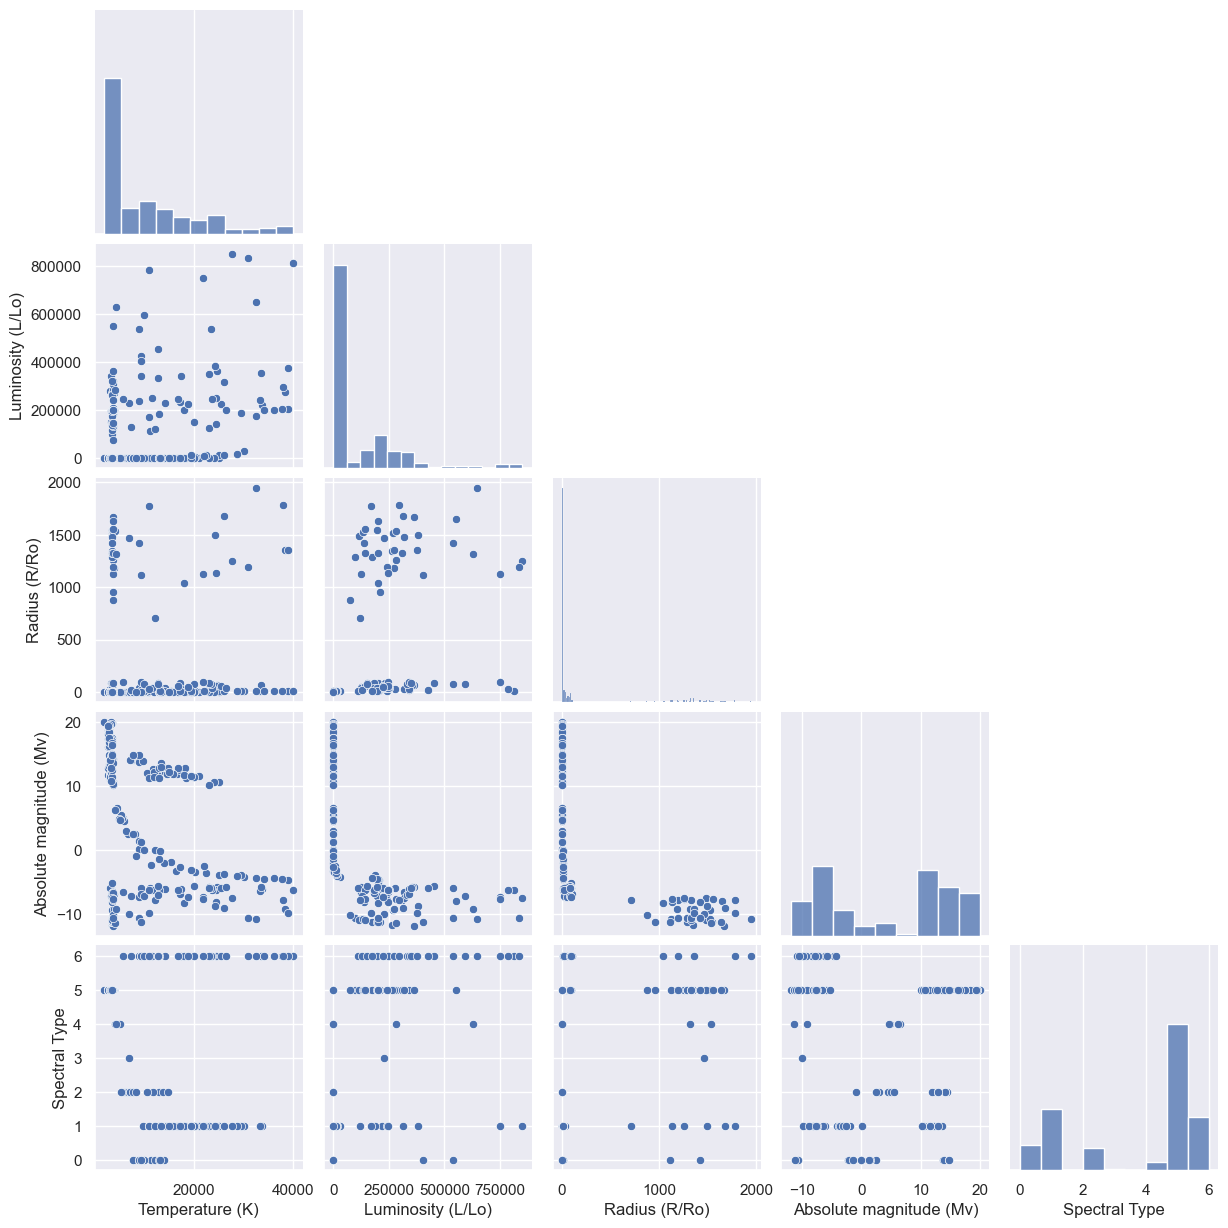

In [57]:
sns.pairplot(stars, vars=['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Spectral Type'], corner=True, kind="scatter", diag_kind="hist")

Most data is not evenly distributed; it skews toward lower values, which indicates outliers at the higher end.

The Spectral Type column shows more high values, but this is just a random mapping to spectral classes and doesn't represent real meaning. Similarly, correlations with Spectral Type don't matter, as the plots show no real correlation.

Absolute magnitude shows some negative correlations with the other columns.

Based on your observations above, perform the necessary data processing on the dataset. Consider these techniques:

- Handling missing values (imputing or dropping)
- Normalization or standardization
- One-hot encoding
- Other relevant preprocessing

Remember to drop columns that could cause a data leak!

In [58]:
stars_cleaned = stars.drop('Spectral Type', axis=1)

In [59]:
def normalizeData(column):
    data_to_scale = column.values.reshape((len(column), 1))
    scaler = preprocessing.StandardScaler()
    scaler = scaler.fit(data_to_scale)
    data_normalized = scaler.transform(data_to_scale)
    return data_normalized

In [60]:
stars_cleaned['Temperature (K)'] = normalizeData(stars['Temperature (K)'])
stars_cleaned['Luminosity (L/Lo)'] = normalizeData(stars['Luminosity (L/Lo)'])
stars_cleaned['Radius (R/Ro)'] = normalizeData(stars['Radius (R/Ro)'])
stars_cleaned['Absolute magnitude (Mv)'] = normalizeData(stars['Absolute magnitude (Mv)'])

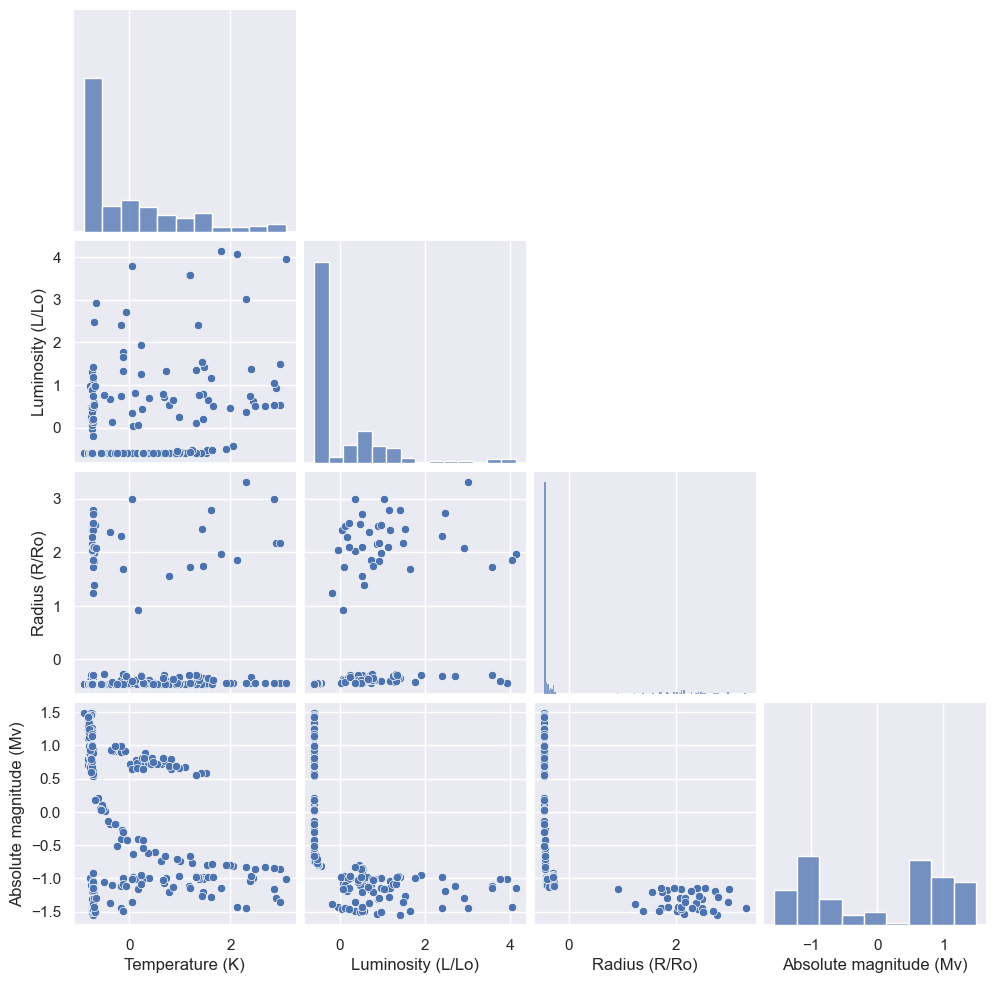

In [61]:
sns.pairplot(stars_cleaned, vars=['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)'], corner=True, kind="scatter", diag_kind="hist")

In [62]:
stars_cleaned = pd.get_dummies(stars_cleaned, columns = ['Star category', 'Star color'], dtype='int')
stars_cleaned.head()

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Spectral Class,Star category_Brown Dwarf,Star category_Hypergiant,Star category_Main Sequence,Star category_Red Dwarf,Star category_Supergiant,...,Star color_Pale yellow orange,Star color_Red,Star color_White,Star color_White-Yellow,Star color_Whitish,Star color_Yellowish,Star color_Yellowish White,Star color_white,Star color_yellow-white,Star color_yellowish
0,-0.779382,-0.598624,-0.459210,1.116745,M,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,-0.782110,-0.598624,-0.459241,1.162414,M,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,-0.828477,-0.598624,-0.459342,1.362213,M,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,-0.807496,-0.598624,-0.459229,1.167171,M,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,-0.897819,-0.598624,-0.459340,1.491607,M,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


Create a new model with your processed dataset. Evaluate it again in the same way as your original model (25% as testing data, heatmap, accuracy score) and compare. What changed?

In [63]:
X = stars_cleaned.drop('Spectral Class', axis=1)
Y = stars_cleaned['Spectral Class']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25) 

In [64]:
X_train.shape

(180, 29)

In [65]:
X_test.shape

(60, 29)

In [66]:
ML_model = RandomForestClassifier()
ML_model.fit(X_train, y_train)
ML_model

RandomForestClassifier()

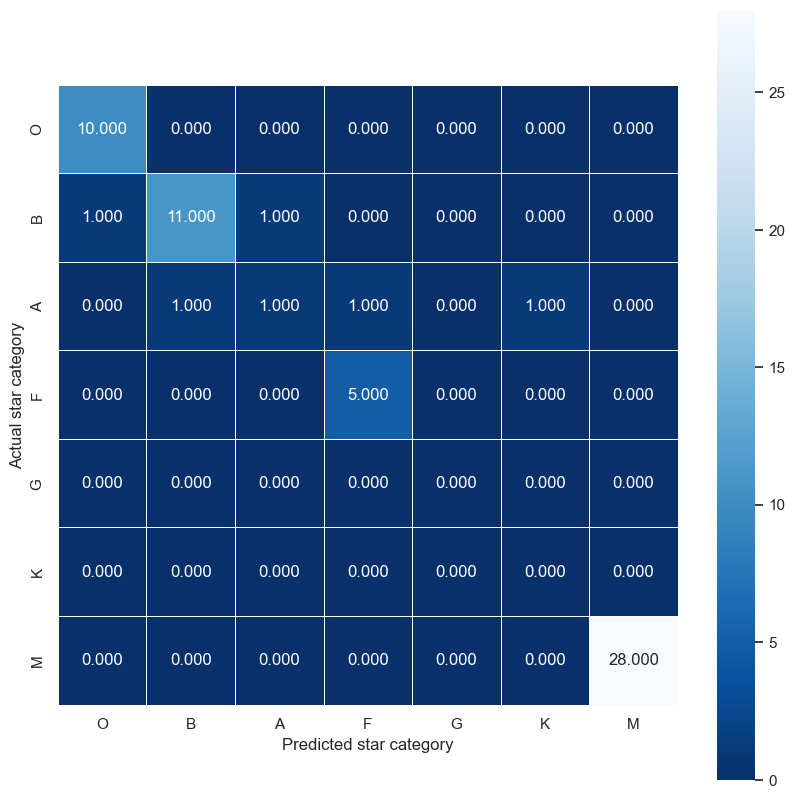

In [67]:
y_pred = ML_model.predict(X_test)

labels = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual star category');
plt.xlabel('Predicted star category');

In [68]:
ML_model.score(X_test, y_test)

0.9166666666666666

We now have an accuracy of 0.97, meaning 97% of our predictions are correct. That's a significant improvement! 📈

The trade-off is that we now have 29 columns instead of 4. While this seems like a lot, advanced techniques in later courses will help reduce dimensionality. We'll also explore some strategies next week to manage this better!